# Project 11: Index Tracking and Forward Testing (US Stocks)

In [1]:
import pandas as pd

In [2]:
const = pd.read_csv("const_prices.csv", parse_dates=["Date"], index_col="Date")

In [3]:
const.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3334 entries, 2007-01-03 to 2020-03-30
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    3333 non-null   float64
 1   AXP     3333 non-null   float64
 2   BA      3333 non-null   float64
 3   CAT     3333 non-null   float64
 4   CSCO    3333 non-null   float64
 5   CVX     3333 non-null   float64
 6   DIS     3333 non-null   float64
 7   DOW     260 non-null    float64
 8   GS      3333 non-null   float64
 9   HD      3333 non-null   float64
 10  IBM     3333 non-null   float64
 11  INTC    3333 non-null   float64
 12  JNJ     3333 non-null   float64
 13  JPM     3333 non-null   float64
 14  KO      3333 non-null   float64
 15  MCD     3333 non-null   float64
 16  MMM     3333 non-null   float64
 17  MRK     3333 non-null   float64
 18  MSFT    3333 non-null   float64
 19  NKE     3333 non-null   float64
 20  PFE     3333 non-null   float64
 21  PG      3333 non-nu

In [4]:
dji = pd.read_csv("dji.csv", parse_dates=["Date"], index_col="Date")
dji

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2007-01-03,12459.540039,12580.349609,12404.820312,12474.519531,12474.519531,327200000
2007-01-04,12473.160156,12510.410156,12403.860352,12480.690430,12480.690430,259060000
2007-01-05,12480.049805,12480.129883,12365.410156,12398.009766,12398.009766,235220000
2007-01-08,12392.009766,12445.919922,12337.370117,12423.490234,12423.490234,223500000
2007-01-09,12424.769531,12466.429688,12369.169922,12416.599609,12416.599609,225190000
...,...,...,...,...,...,...
2020-03-24,19722.189453,20737.699219,19649.250000,20704.910156,20704.910156,799340000
2020-03-25,21050.339844,22019.929688,20538.339844,21200.550781,21200.550781,796320000
2020-03-26,21468.380859,22595.060547,21427.099609,22552.169922,22552.169922,705180000


In [5]:
dji = dji.Close.to_frame().copy()
dji

,Close
Date,
2007-01-03,12474.519531
2007-01-04,12480.690430
2007-01-05,12398.009766
2007-01-08,12423.490234
2007-01-09,12416.599609
...,...
2020-03-24,20704.910156
2020-03-25,21200.550781
2020-03-26,22552.169922


In [6]:
df = pd.concat([const, dji], axis=1)
df

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,Close
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-03,11.971429,60.360001,89.169998,61.160000,27.730000,70.970001,33.738300,NaN,200.720001,41.070000,...,64.540001,39.528004,53.549999,52.570000,NaN,35.306732,46.070000,47.549999,74.110001,12474.519531
2007-01-04,12.237143,59.919998,89.529999,61.000000,28.459999,70.279999,34.004654,NaN,198.850006,40.570000,...,64.050003,39.565765,53.099998,52.910000,NaN,35.502777,46.160000,47.779999,72.720001,12480.690430
2007-01-05,12.150000,59.130001,89.150002,60.220001,28.469999,70.550003,33.728436,NaN,199.050003,39.790001,...,63.500000,39.446194,52.410000,52.549999,NaN,34.895969,45.500000,47.389999,73.239998,12398.009766
2007-01-08,12.210000,59.689999,88.940002,60.290001,28.629999,71.449997,34.034248,NaN,203.729996,39.490002,...,63.639999,39.767151,52.020000,53.320000,NaN,34.363850,45.689999,47.000000,72.650002,12423.490234
2007-01-09,13.224286,59.310001,88.000000,60.619999,28.469999,70.629997,33.984924,NaN,204.080002,39.320000,...,63.480000,39.314034,51.889999,52.680000,NaN,34.503880,45.930000,47.389999,72.089996,12416.599609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-24,246.880005,84.050003,127.680000,101.339996,38.599998,66.550003,98.120003,28.469999,153.600006,184.720001,...,103.269997,54.600376,93.739998,219.800003,154.529999,49.990002,45.250000,115.029999,35.439999,20704.910156
2020-03-25,245.520004,90.169998,158.729996,104.669998,37.669998,69.269997,100.730003,30.379999,155.130005,181.759995,...,100.919998,60.534927,92.180000,234.490005,161.779999,49.939999,41.439999,109.400002,37.290001,21200.550781
2020-03-26,258.440002,93.290001,180.550003,110.500000,40.580002,76.379997,105.360001,29.680000,165.789993,195.210007,...,107.379997,65.852737,98.669998,255.389999,168.880005,53.540001,45.669998,109.820000,38.820000,22552.169922


In [7]:
df.rename(columns={"Close": "DJI"}, inplace=True)

In [8]:
more_info = pd.read_csv("const.csv")
more_info

,Company,Exchange,Symbol,Industry,Date_Added,Ticker
0,3M,NYSE,NYSE: MMM,Conglomerate,1976-08-09,MMM
1,American Express,NYSE,NYSE: AXP,Financial services,1982-08-30,AXP
2,Apple Inc.,NASDAQ,AAPL,Information technology,2015-03-19,AAPL
3,Boeing,NYSE,NYSE: BA,Aerospace and defense,1987-03-12,BA
4,Caterpillar Inc.,NYSE,NYSE: CAT,Construction and Mining,1991-05-06,CAT
5,Chevron Corporation,NYSE,NYSE: CVX,Petroleum industry,2008-02-19,CVX
6,Cisco Systems,NASDAQ,CSCO,Information technology,2009-06-08,CSCO
7,The Coca-Cola Company,NYSE,NYSE: KO,Food industry,1987-03-12,KO
8,Dow Inc.,NYSE,NYSE: DOW,Chemical industry,2019-04-02,DOW
9,ExxonMobil,NYSE,NYSE: XOM,Petroleum industry,1928-10-01,XOM


## Transforming the Data

In [9]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("seaborn-v0_8")

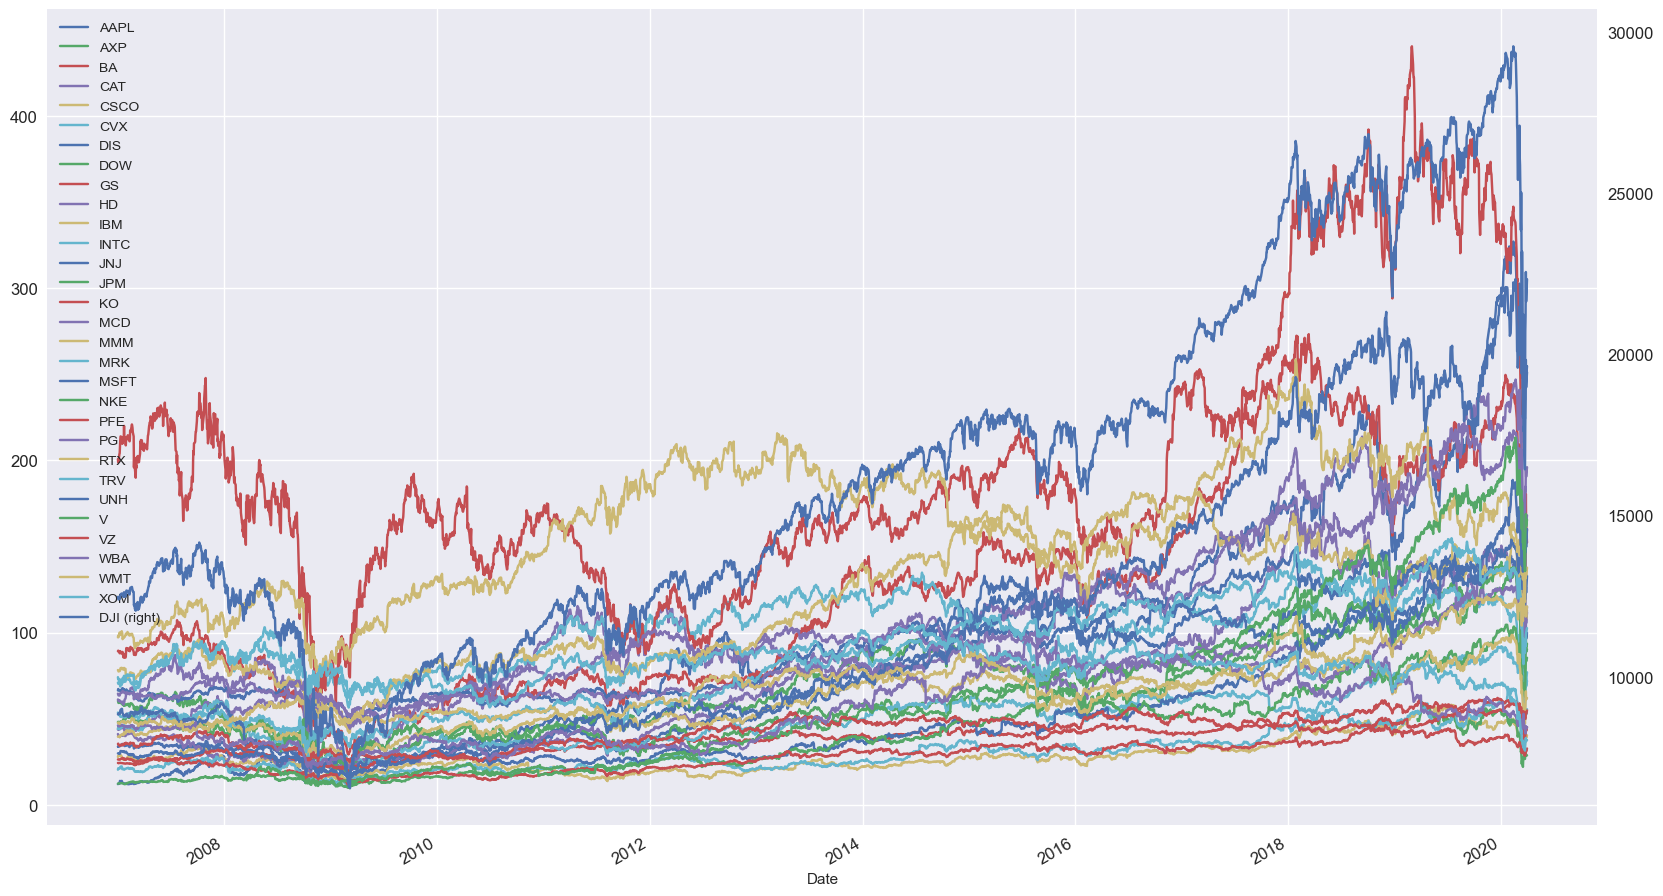

In [10]:
df.plot(figsize=(20,12), fontsize=12, secondary_y="DJI")
plt.show()

In [11]:
df.div(df.iloc[0]).mul(100)

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,NaN,100.000000,100.000000,100.000000,100.000000,100.000000
2007-01-04,102.219565,99.271036,100.403724,99.738391,102.632526,99.027755,100.789470,NaN,99.068356,98.782566,...,99.240784,100.095531,99.159662,100.646757,NaN,100.555262,100.195355,100.483700,98.124411,100.049468
2007-01-05,101.491641,97.962227,99.977575,98.463050,102.668589,99.408203,99.970761,NaN,99.167996,96.883373,...,98.388595,99.793033,97.871150,99.961955,NaN,98.836588,98.762753,99.663512,98.826066,99.386672
2007-01-08,101.992838,98.889990,99.742071,98.577503,103.245581,100.676336,100.877187,NaN,101.499599,96.152914,...,98.605514,100.605007,97.142859,101.426669,NaN,97.329454,99.175166,98.843324,98.029957,99.590932
2007-01-09,110.465394,98.260439,98.687902,99.117068,102.668589,99.520919,100.730991,NaN,101.673974,95.738982,...,98.357606,99.458687,96.900094,100.209246,NaN,97.726064,99.696116,99.663512,97.274316,99.535694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-24,2062.243426,139.247850,143.187174,165.696528,139.199420,93.772019,290.826751,NaN,76.524514,449.768694,...,160.009289,138.130872,175.051352,418.109196,NaN,141.587733,98.220100,241.913776,47.820805,165.977616
2020-03-25,2050.883039,149.387007,178.008298,171.141266,135.845650,97.604615,298.562768,NaN,77.286770,442.561470,...,156.368139,153.144408,172.138192,446.052895,NaN,141.446108,89.950074,230.073614,50.317097,169.950840
2020-03-26,2158.806649,154.555997,202.478420,180.673643,146.339713,107.622934,312.286036,NaN,82.597645,475.310465,...,166.377434,166.597681,184.257702,485.809399,NaN,151.642470,99.131753,230.956891,52.381594,180.785880


In [12]:
norm = df.div(df.iloc[0].mul(100))
norm

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-03,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,NaN,0.010000,0.010000,...,0.010000,0.010000,0.010000,0.010000,NaN,0.010000,0.010000,0.010000,0.010000,0.010000
2007-01-04,0.010222,0.009927,0.010040,0.009974,0.010263,0.009903,0.010079,NaN,0.009907,0.009878,...,0.009924,0.010010,0.009916,0.010065,NaN,0.010056,0.010020,0.010048,0.009812,0.010005
2007-01-05,0.010149,0.009796,0.009998,0.009846,0.010267,0.009941,0.009997,NaN,0.009917,0.009688,...,0.009839,0.009979,0.009787,0.009996,NaN,0.009884,0.009876,0.009966,0.009883,0.009939
2007-01-08,0.010199,0.009889,0.009974,0.009858,0.010325,0.010068,0.010088,NaN,0.010150,0.009615,...,0.009861,0.010061,0.009714,0.010143,NaN,0.009733,0.009918,0.009884,0.009803,0.009959
2007-01-09,0.011047,0.009826,0.009869,0.009912,0.010267,0.009952,0.010073,NaN,0.010167,0.009574,...,0.009836,0.009946,0.009690,0.010021,NaN,0.009773,0.009970,0.009966,0.009727,0.009954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-24,0.206224,0.013925,0.014319,0.016570,0.013920,0.009377,0.029083,NaN,0.007652,0.044977,...,0.016001,0.013813,0.017505,0.041811,NaN,0.014159,0.009822,0.024191,0.004782,0.016598
2020-03-25,0.205088,0.014939,0.017801,0.017114,0.013585,0.009760,0.029856,NaN,0.007729,0.044256,...,0.015637,0.015314,0.017214,0.044605,NaN,0.014145,0.008995,0.023007,0.005032,0.016995
2020-03-26,0.215881,0.015456,0.020248,0.018067,0.014634,0.010762,0.031229,NaN,0.008260,0.047531,...,0.016638,0.016660,0.018426,0.048581,NaN,0.015164,0.009913,0.023096,0.005238,0.018079


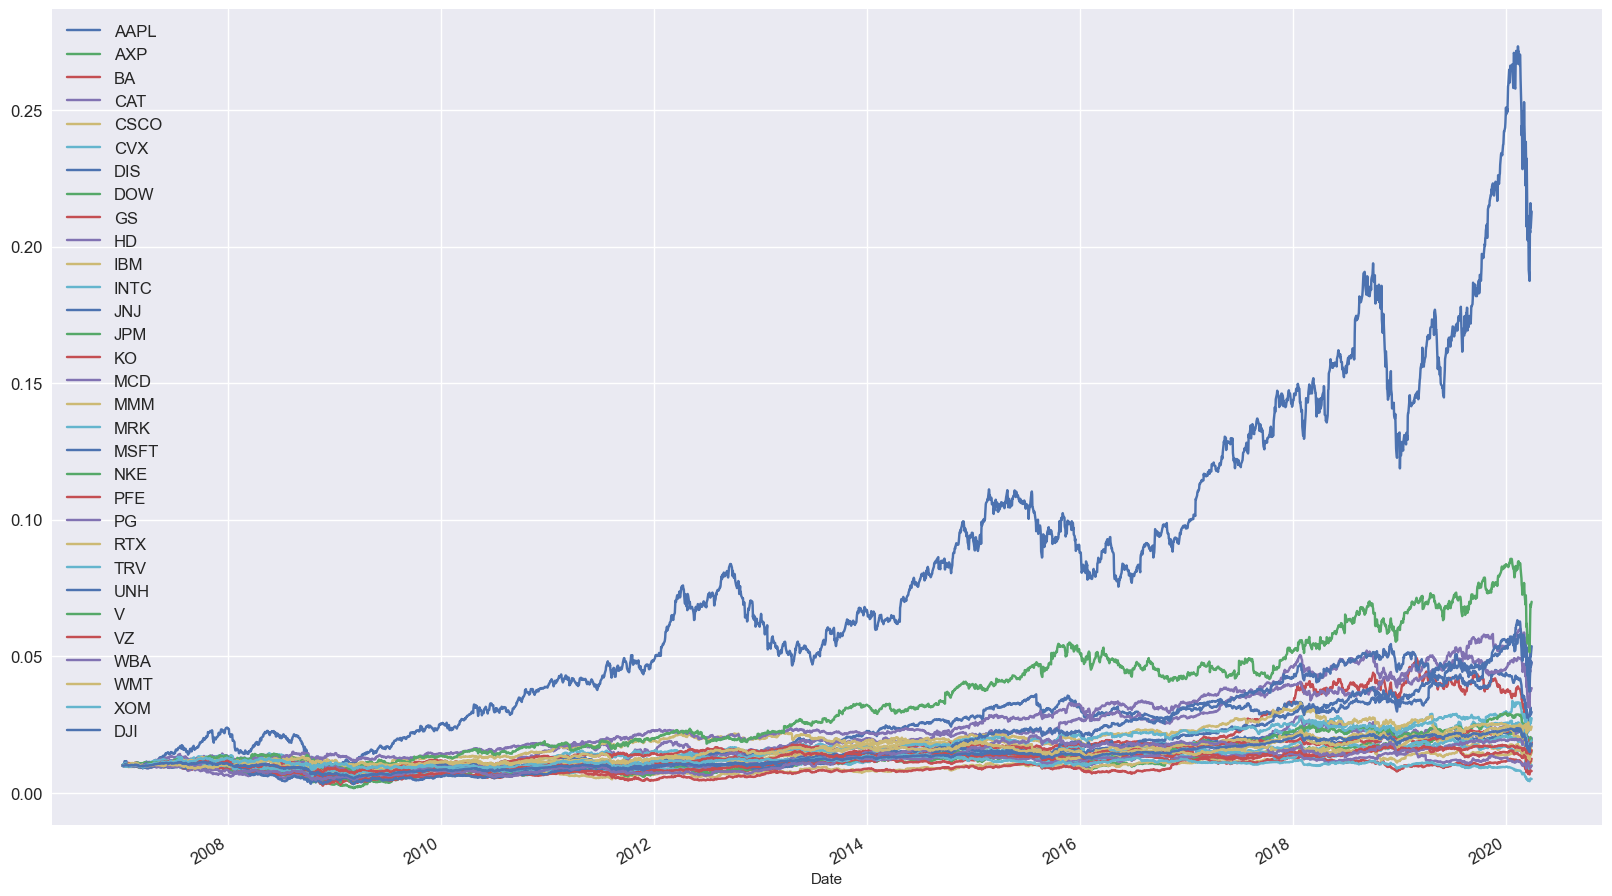

In [13]:
norm.plot(figsize=(20,12), fontsize=12)
plt.legend(fontsize=12)
plt.show()

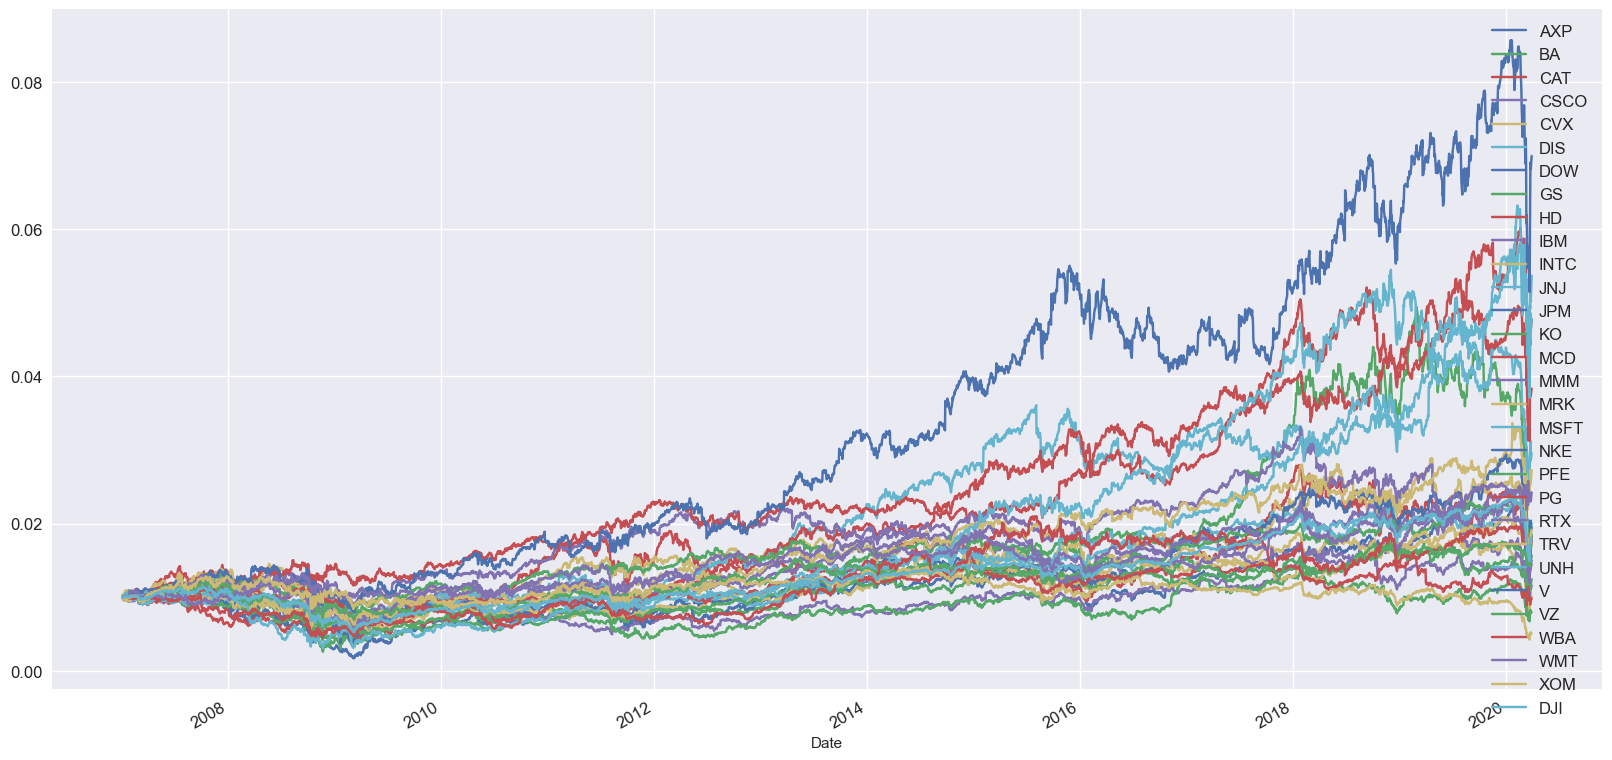

In [14]:
norm.drop(columns=["AAPL"]).plot(figsize=(20,10), fontsize=12)
plt.legend(fontsize=12)
plt.show()

In [15]:
ret = df.pct_change(fill_method=None)
ret

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-04,0.022196,-0.007290,0.004037,-0.002616,0.026325,-0.009722,0.007895,NaN,-0.009316,-0.012174,...,-0.007592,0.000955,-0.008403,0.006468,NaN,0.005553,0.001954,0.004837,-0.018756,0.000495
2007-01-05,-0.007121,-0.013184,-0.004244,-0.012787,0.000351,0.003842,-0.008123,NaN,0.001006,-0.019226,...,-0.008587,-0.003022,-0.012994,-0.006804,NaN,-0.017092,-0.014298,-0.008162,0.007151,-0.006625
2007-01-08,0.004938,0.009471,-0.002356,0.001162,0.005620,0.012757,0.009067,NaN,0.023512,-0.007540,...,0.002205,0.008137,-0.007441,0.014653,NaN,-0.015249,0.004176,-0.008230,-0.008056,0.002055
2007-01-09,0.083070,-0.006366,-0.010569,0.005474,-0.005589,-0.011477,-0.001449,NaN,0.001718,-0.004305,...,-0.002514,-0.011394,-0.002499,-0.012003,NaN,0.004075,0.005253,0.008298,-0.007708,-0.000555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-24,0.100325,0.218823,0.208862,0.103321,0.115607,0.227407,0.144123,0.071106,0.138031,0.137508,...,0.057011,0.157572,0.060887,0.127989,0.138426,-0.006361,0.037606,0.006563,0.126868,0.113650
2020-03-25,-0.005509,0.072814,0.243186,0.032860,-0.024093,0.040871,0.026600,0.067088,0.009961,-0.016024,...,-0.022756,0.108691,-0.016642,0.066833,0.046916,-0.001000,-0.084199,-0.048944,0.052201,0.023938
2020-03-26,0.052623,0.034601,0.137466,0.055699,0.077250,0.102642,0.045964,-0.023041,0.068716,0.073999,...,0.064011,0.087847,0.070406,0.089130,0.043887,0.072087,0.102075,0.003839,0.041030,0.063754


In [16]:
ret.describe()

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
count,3331.000000,3331.000000,3331.000000,3331.000000,3331.000000,3331.000000,3331.000000,259.000000,3331.000000,3331.000000,...,3331.000000,3331.000000,3331.000000,3331.000000,3027.000000,3331.000000,3331.000000,3331.000000,3331.000000,3331.000000
mean,0.001126,0.000405,0.000374,0.000397,0.000285,0.000179,0.000476,-0.001557,0.000219,0.000617,...,0.000237,0.000265,0.000360,0.000681,0.000999,0.000222,0.000150,0.000346,-0.000073,0.000251
std,0.020291,0.023868,0.020639,0.020604,0.018737,0.018264,0.017389,0.033533,0.024190,0.017248,...,0.011922,0.015991,0.018260,0.021072,0.019161,0.013664,0.017830,0.012963,0.015948,0.012398
min,-0.179195,-0.175949,-0.238484,-0.142822,-0.162107,-0.221248,-0.129846,-0.216577,-0.189596,-0.197938,...,-0.087373,-0.144765,-0.208004,-0.186362,-0.136435,-0.080685,-0.149873,-0.101832,-0.139525,-0.129265
25%,-0.007885,-0.007508,-0.008625,-0.008943,-0.007328,-0.007599,-0.006842,-0.014935,-0.009636,-0.006983,...,-0.004802,-0.006493,-0.006245,-0.008107,-0.007500,-0.006512,-0.008172,-0.005575,-0.007152,-0.003937
50%,0.000990,0.000647,0.000694,0.000398,0.000443,0.000638,0.000572,0.000554,0.000258,0.000528,...,0.000250,0.000508,0.000668,0.000616,0.001230,0.000525,0.000105,0.000540,0.000000,0.000560
75%,0.011174,0.009356,0.009970,0.010254,0.008706,0.008353,0.008108,0.012207,0.010241,0.008163,...,0.005527,0.007681,0.007367,0.009274,0.009249,0.006994,0.008872,0.006329,0.007248,0.005291
max,0.139050,0.218823,0.243186,0.147229,0.159505,0.227407,0.159722,0.209091,0.264678,0.140666,...,0.120090,0.157572,0.255556,0.347550,0.149973,0.146324,0.166355,0.117085,0.171905,0.113650


In [17]:
def summary_ann(returns):
    summary = returns.agg(["mean", "std"]).T
    summary["Return"] = summary["mean"] * 252
    summary["Risk"] = summary["std"] * np.sqrt(252)
    summary.drop(columns=["mean", "std"], inplace=True)
    return summary

In [18]:
summary = summary_ann(ret)
summary

,Return,Risk
AAPL,0.283862,0.322103
AXP,0.102132,0.378898
BA,0.094275,0.327635
CAT,0.100134,0.327077
CSCO,0.071937,0.297436
CVX,0.045228,0.289926
DIS,0.119970,0.276041
DOW,-0.392383,0.532319
GS,0.055148,0.383999
HD,0.155489,0.273806


In [19]:
summary = summary.merge(more_info.loc[:, ["Ticker", "Company"]], how="left", left_index=True, right_on="Ticker")

In [20]:
summary.set_index("Company", inplace=True)
summary

,Return,Risk,Ticker
Company,,,
Apple Inc.,0.283862,0.322103,AAPL
American Express,0.102132,0.378898,AXP
Boeing,0.094275,0.327635,BA
Caterpillar Inc.,0.100134,0.327077,CAT
Cisco Systems,0.071937,0.297436,CSCO
Chevron Corporation,0.045228,0.289926,CVX
The Walt Disney Company,0.119970,0.276041,DIS
Dow Inc.,-0.392383,0.532319,DOW
Goldman Sachs,0.055148,0.383999,GS


In [21]:
summary.rename(index={np.nan: "Dow Jones"}, inplace=True)
summary

,Return,Risk,Ticker
Company,,,
Apple Inc.,0.283862,0.322103,AAPL
American Express,0.102132,0.378898,AXP
Boeing,0.094275,0.327635,BA
Caterpillar Inc.,0.100134,0.327077,CAT
Cisco Systems,0.071937,0.297436,CSCO
Chevron Corporation,0.045228,0.289926,CVX
The Walt Disney Company,0.119970,0.276041,DIS
Dow Inc.,-0.392383,0.532319,DOW
Goldman Sachs,0.055148,0.383999,GS


## Explanatory Data Analysis

In [22]:
ret.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3334 entries, 2007-01-03 to 2020-03-30
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    3331 non-null   float64
 1   AXP     3331 non-null   float64
 2   BA      3331 non-null   float64
 3   CAT     3331 non-null   float64
 4   CSCO    3331 non-null   float64
 5   CVX     3331 non-null   float64
 6   DIS     3331 non-null   float64
 7   DOW     259 non-null    float64
 8   GS      3331 non-null   float64
 9   HD      3331 non-null   float64
 10  IBM     3331 non-null   float64
 11  INTC    3331 non-null   float64
 12  JNJ     3331 non-null   float64
 13  JPM     3331 non-null   float64
 14  KO      3331 non-null   float64
 15  MCD     3331 non-null   float64
 16  MMM     3331 non-null   float64
 17  MRK     3331 non-null   float64
 18  MSFT    3331 non-null   float64
 19  NKE     3331 non-null   float64
 20  PFE     3331 non-null   float64
 21  PG      3331 non-nu

In [23]:
summary2 = summary.drop(index="Dow Inc.")
summary2

,Return,Risk,Ticker
Company,,,
Apple Inc.,0.283862,0.322103,AAPL
American Express,0.102132,0.378898,AXP
Boeing,0.094275,0.327635,BA
Caterpillar Inc.,0.100134,0.327077,CAT
Cisco Systems,0.071937,0.297436,CSCO
Chevron Corporation,0.045228,0.289926,CVX
The Walt Disney Company,0.119970,0.276041,DIS
Goldman Sachs,0.055148,0.383999,GS
The Home Depot,0.155489,0.273806,HD


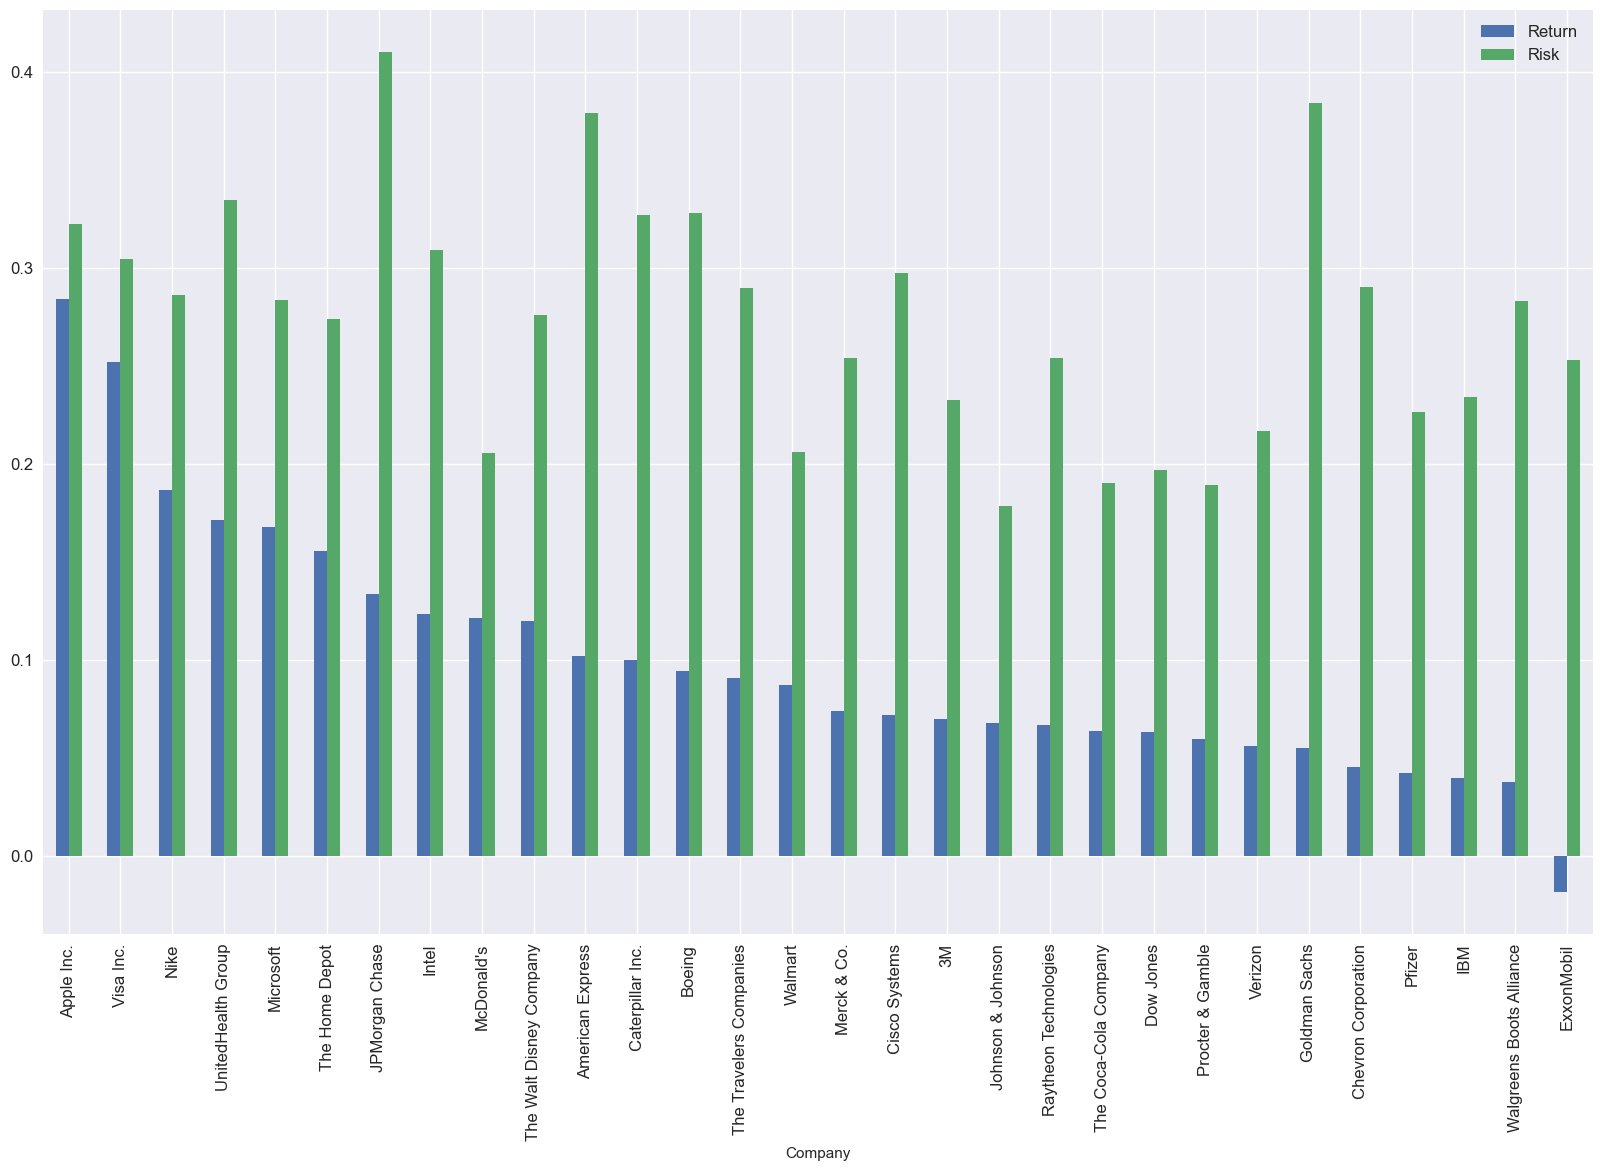

In [24]:
summary2.sort_values(by="Return", ascending=False).plot(kind="bar", figsize=(20,12), fontsize=12)
plt.legend(fontsize=12)
plt.show()

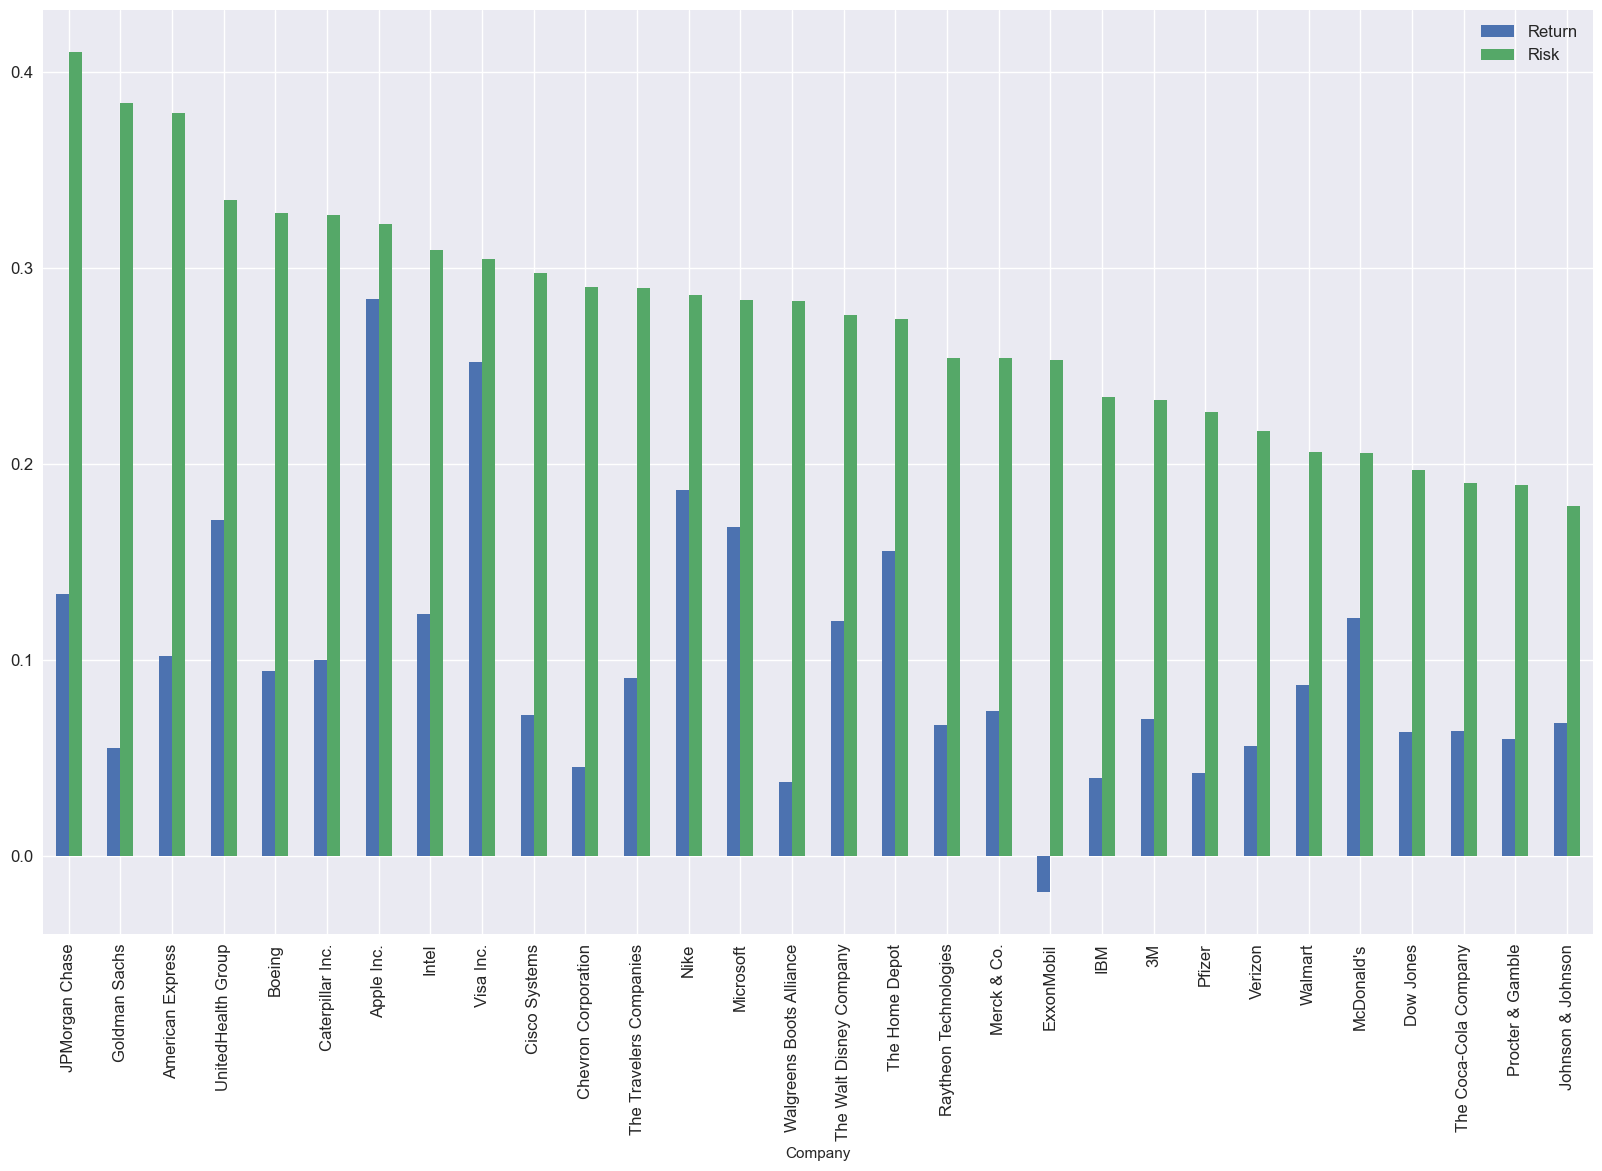

In [25]:
summary2.sort_values(by="Risk", ascending=False).plot(kind="bar", figsize=(20,12), fontsize=12)
plt.legend(fontsize=12)
plt.show()

In [26]:
summary2.set_index("Ticker", inplace=True)
summary2

,Return,Risk
Ticker,,
AAPL,0.283862,0.322103
AXP,0.102132,0.378898
BA,0.094275,0.327635
CAT,0.100134,0.327077
CSCO,0.071937,0.297436
CVX,0.045228,0.289926
DIS,0.119970,0.276041
GS,0.055148,0.383999
HD,0.155489,0.273806


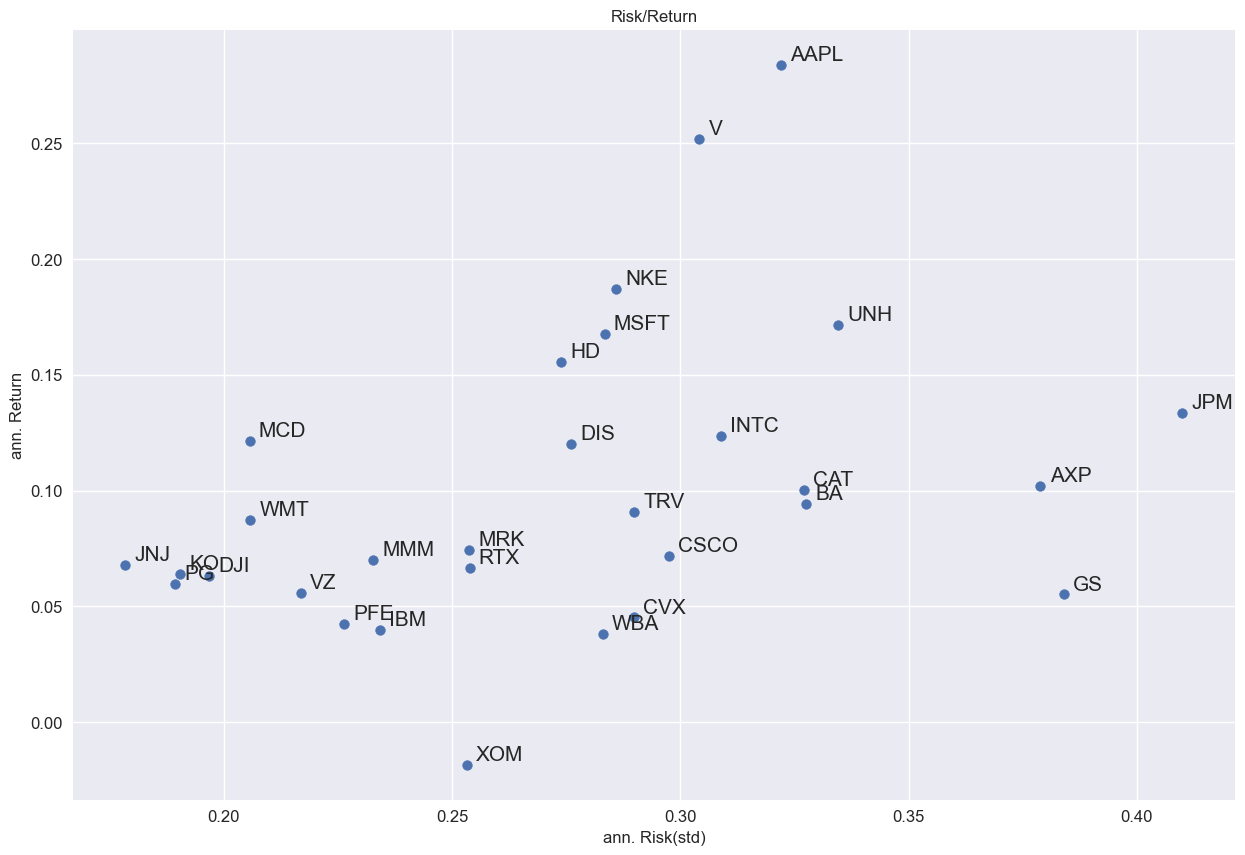

In [27]:
summary2.plot(kind="scatter", x="Risk", y="Return", figsize=(15,10), s=50, fontsize=12)
for i in summary2.index:
    plt.annotate(i, xy=(summary2.loc[i, "Risk"]+0.002, summary2.loc[i, "Return"]+0.002), size=15)
plt.xlabel("ann. Risk(std)", fontsize=12)
plt.ylabel("ann. Return", fontsize=12)
plt.title("Risk/Return", fontsize=12)
plt.show()

In [28]:
corr_matrix = ret.corr()
corr_matrix

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
AAPL,1.000000,0.480035,0.438106,0.487207,0.525420,0.449069,0.468587,0.631347,0.476732,0.463357,...,0.363774,0.497997,0.426428,0.390917,0.500850,0.355567,0.358414,0.322550,0.440529,0.621948
AXP,0.480035,1.000000,0.550152,0.595989,0.552282,0.573152,0.627937,0.585071,0.681497,0.602901,...,0.469888,0.632655,0.604667,0.463559,0.608319,0.462185,0.396389,0.372173,0.543953,0.771372
BA,0.438106,0.550152,1.000000,0.554072,0.485745,0.571901,0.566122,0.502373,0.501915,0.527700,...,0.418076,0.680832,0.465488,0.437525,0.470864,0.378062,0.368813,0.331802,0.562352,0.736428
CAT,0.487207,0.595989,0.554072,1.000000,0.568573,0.617187,0.585413,0.759624,0.565850,0.527029,...,0.412225,0.655213,0.473500,0.399553,0.501086,0.433922,0.402759,0.357485,0.617173,0.760286
CSCO,0.525420,0.552282,0.485745,0.568573,1.000000,0.533994,0.583030,0.596760,0.546365,0.531222,...,0.476460,0.587841,0.482393,0.405170,0.511060,0.459427,0.427108,0.416788,0.550935,0.727902
CVX,0.449069,0.573152,0.571901,0.617187,0.533994,1.000000,0.600222,0.541230,0.557286,0.531745,...,0.491348,0.652974,0.571049,0.498295,0.509176,0.475525,0.390493,0.360487,0.850657,0.787468
DIS,0.468587,0.627937,0.566122,0.585413,0.583030,0.600222,1.000000,0.524249,0.584604,0.595527,...,0.531116,0.649864,0.543401,0.475580,0.531933,0.487717,0.442792,0.423201,0.604535,0.781624
DOW,0.631347,0.585071,0.502373,0.759624,0.596760,0.541230,0.524249,1.000000,0.660349,0.568539,...,0.495249,0.589982,0.565861,0.505610,0.613575,0.451777,0.431488,0.489743,0.705081,0.714794
GS,0.476732,0.681497,0.501915,0.565850,0.546365,0.557286,0.584604,0.660349,1.000000,0.566175,...,0.404848,0.572200,0.569971,0.455341,0.553404,0.419985,0.389826,0.349418,0.533608,0.729826
HD,0.463357,0.602901,0.527700,0.527029,0.531222,0.531745,0.595527,0.568539,0.566175,1.000000,...,0.481521,0.603183,0.552372,0.460473,0.535104,0.480412,0.444274,0.490322,0.512175,0.748405


In [29]:
import seaborn as sns

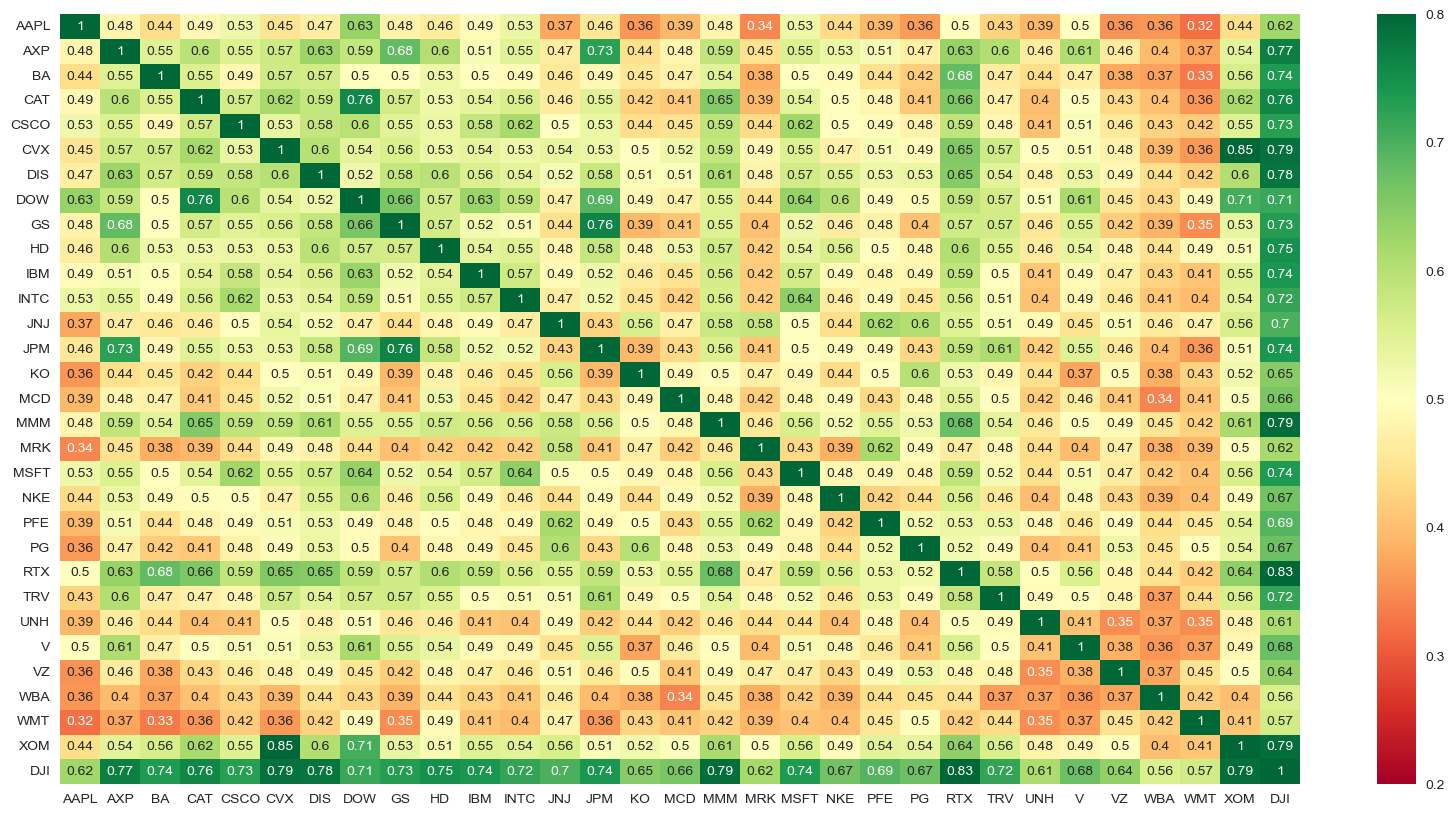

In [30]:
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, cmap="RdYlGn", annot=True, vmin=0.2, vmax=0.8)
plt.show()

## Index Tracking - an Introduction

Plan: Track the DJI with only __10 Stocks__ (Tracking Portfolio).

Criteria to select Tracking Portfolio: Those 10 Stocks with the __lowest individual Tracking Error__ (TE) in the Training/Fitting Period.

- Training/Fitting Period: 2017 & 2018
- (Forward) Testing Period: 2019

Once we have identified the 10 Tracking Stocks we need to find their __optimal weights__ in the Tracking Portfolio that __minimize TE__.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3334 entries, 2007-01-03 to 2020-03-30
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    3333 non-null   float64
 1   AXP     3333 non-null   float64
 2   BA      3333 non-null   float64
 3   CAT     3333 non-null   float64
 4   CSCO    3333 non-null   float64
 5   CVX     3333 non-null   float64
 6   DIS     3333 non-null   float64
 7   DOW     260 non-null    float64
 8   GS      3333 non-null   float64
 9   HD      3333 non-null   float64
 10  IBM     3333 non-null   float64
 11  INTC    3333 non-null   float64
 12  JNJ     3333 non-null   float64
 13  JPM     3333 non-null   float64
 14  KO      3333 non-null   float64
 15  MCD     3333 non-null   float64
 16  MMM     3333 non-null   float64
 17  MRK     3333 non-null   float64
 18  MSFT    3333 non-null   float64
 19  NKE     3333 non-null   float64
 20  PFE     3333 non-null   float64
 21  PG      3333 non-nu

In [32]:
df2 = df.loc["2017":"2018"].copy()
df2

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,116.150002,75.349998,156.970001,93.989998,30.540001,117.849998,106.080002,NaN,241.570007,134.309998,...,84.199997,69.748268,120.900002,161.449997,79.500000,54.580002,82.959999,68.660004,90.889999,19881.759766
2017-01-04,116.019997,76.260002,158.619995,93.570000,30.100000,117.820000,107.440002,NaN,243.130005,135.500000,...,84.500000,69.792320,120.250000,161.910004,80.150002,54.520000,82.980003,69.059998,89.889999,19942.160156
2017-01-05,116.610001,75.320000,158.710007,93.000000,30.170000,117.309998,107.379997,NaN,241.320007,133.899994,...,85.059998,70.075516,118.330002,162.179993,81.089996,54.639999,83.029999,69.209999,88.550003,19899.289062
2017-01-06,117.910004,75.470001,159.100006,93.040001,30.230000,116.839996,108.980003,NaN,244.899994,133.529999,...,85.029999,70.830711,118.269997,162.410004,82.209999,53.259998,83.099998,68.260002,88.500000,19963.800781
2017-01-09,118.989998,75.860001,158.320007,92.370003,30.180000,115.839996,108.360001,NaN,242.889999,134.309998,...,84.400002,70.169922,117.320000,161.949997,81.750000,52.680000,82.550003,68.709999,87.040001,19887.380859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,146.830002,89.500000,294.160004,116.949997,40.279999,100.989998,100.349998,NaN,156.350006,158.139999,...,87.360001,64.229073,112.629997,232.940002,121.730003,53.049999,65.260002,85.820000,65.510002,21792.199219
2018-12-26,157.169998,93.839996,313.929993,124.760002,42.470001,107.389999,105.830002,NaN,162.929993,168.279999,...,90.089996,66.714912,117.169998,243.350006,130.229996,54.439999,67.720001,90.410004,68.639999,22878.449219
2018-12-27,156.149994,94.680000,317.140015,126.669998,42.910000,109.320000,106.519997,NaN,165.410004,170.320007,...,92.019997,66.557587,118.669998,245.970001,132.009995,55.150002,68.360001,91.589996,68.940002,23138.820312


In [33]:
norm2 = df2.div(df2.iloc[0]).mul(100)
norm2

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2017-01-04,99.888072,101.207702,101.051152,99.553146,98.559265,99.974545,101.282052,NaN,100.645775,100.886012,...,100.356298,100.063159,99.462364,100.284922,100.817612,99.890067,100.024113,100.582572,98.899769,100.303798
2017-01-05,100.396039,99.960187,101.108496,98.946699,98.788471,99.541790,101.225486,NaN,99.896510,99.694733,...,101.021378,100.469184,97.874277,100.452150,101.999995,100.109926,100.084378,100.801042,97.425463,100.088168
2017-01-06,101.515284,100.159260,101.356950,98.989257,98.984933,99.142977,102.733787,NaN,101.378477,99.419255,...,100.985750,101.551928,97.824644,100.594616,103.408804,97.581525,100.168755,99.417417,97.370448,100.412645
2017-01-09,102.445111,100.676844,100.860041,98.276418,98.821216,98.294440,102.149320,NaN,100.546422,100.000000,...,100.237535,100.604537,97.038874,100.309693,102.830189,96.518869,99.505791,100.072816,95.764112,100.028273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,126.414120,118.779034,187.398867,124.428130,131.892592,85.693678,94.598413,NaN,64.722441,117.742538,...,103.752974,92.086978,93.159633,144.279967,153.119501,97.196771,78.664420,124.992711,72.076139,109.609006
2018-12-26,135.316398,124.538817,199.993623,132.737531,139.063523,91.124311,99.764329,NaN,67.446284,125.292236,...,106.995249,95.650995,96.914803,150.727786,163.811315,99.743490,81.629703,131.677831,75.519859,115.072556
2018-12-27,134.438219,125.653619,202.038614,134.769657,140.504252,92.761987,100.414776,NaN,68.472906,126.811116,...,109.287411,95.425433,98.155498,152.350577,166.050308,101.044338,82.401159,133.396434,75.849932,116.382154


In [34]:
ret2 = ret.loc["2017":"2018"].copy()
ret2

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,0.002849,0.017144,0.008286,0.013479,0.010589,0.001274,0.017847,NaN,0.008854,0.001715,...,0.001427,0.011038,-0.012416,0.008810,0.018970,0.022480,0.002417,-0.006655,0.006980,0.006030
2017-01-04,-0.001119,0.012077,0.010512,-0.004469,-0.014407,-0.000255,0.012821,NaN,0.006458,0.008860,...,0.003563,0.000632,-0.005376,0.002849,0.008176,-0.001099,0.000241,0.005826,-0.011002,0.003038
2017-01-05,0.005085,-0.012326,0.000567,-0.006092,0.002326,-0.004329,-0.000558,NaN,-0.007445,-0.011808,...,0.006627,0.004058,-0.015967,0.001668,0.011728,0.002201,0.000602,0.002172,-0.014907,-0.002150
2017-01-06,0.011148,0.001992,0.002457,0.000430,0.001989,-0.004006,0.014900,NaN,0.014835,-0.002763,...,-0.000353,0.010777,-0.000507,0.001418,0.013812,-0.025256,0.000843,-0.013726,-0.000565,0.003242
2017-01-09,0.009159,0.005168,-0.004903,-0.007201,-0.001654,-0.008559,-0.005689,NaN,-0.008207,0.005841,...,-0.007409,-0.009329,-0.008032,-0.002832,-0.005595,-0.010890,-0.006618,0.006592,-0.016497,-0.003828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,-0.025874,-0.020037,-0.034116,-0.025985,-0.037515,-0.030899,-0.037133,NaN,-0.023118,-0.014581,...,-0.039683,-0.038802,-0.029554,-0.022657,-0.020361,-0.034050,-0.029735,-0.015035,-0.038315,-0.029100
2018-12-26,0.070422,0.048492,0.067208,0.066781,0.054369,0.063373,0.054609,NaN,0.042085,0.064120,...,0.031250,0.038703,0.040309,0.044690,0.069827,0.026202,0.037695,0.053484,0.047779,0.049846
2018-12-27,-0.006490,0.008951,0.010225,0.015309,0.010360,0.017972,0.006520,NaN,0.015221,0.012123,...,0.021423,-0.002358,0.012802,0.010766,0.013668,0.013042,0.009451,0.013052,0.004371,0.011381


In [35]:
ret_diff = ret2.sub(ret2.DJI, axis=0)
ret_diff

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,-0.003180,0.011114,0.002257,0.007449,0.004559,-0.004755,0.011817,NaN,0.002824,-0.004314,...,-0.004602,0.005009,-0.018446,0.002781,0.012940,0.016451,-0.003613,-0.012685,0.000950,0.0
2017-01-04,-0.004157,0.009039,0.007474,-0.007507,-0.017445,-0.003293,0.009783,NaN,0.003420,0.005822,...,0.000525,-0.002406,-0.008414,-0.000189,0.005138,-0.004137,-0.002797,0.002788,-0.014040,0.0
2017-01-05,0.007235,-0.010177,0.002717,-0.003942,0.004475,-0.002179,0.001591,NaN,-0.005295,-0.009658,...,0.008777,0.006207,-0.013817,0.003817,0.013878,0.004351,0.002752,0.004322,-0.012757,0.0
2017-01-06,0.007906,-0.001250,-0.000785,-0.002812,-0.001253,-0.007248,0.011659,NaN,0.011593,-0.006005,...,-0.003595,0.007535,-0.003749,-0.001824,0.010570,-0.028498,-0.002399,-0.016968,-0.003807,0.0
2017-01-09,0.012987,0.008996,-0.001075,-0.003373,0.002174,-0.004731,-0.001861,NaN,-0.004379,0.009669,...,-0.003581,-0.005501,-0.004205,0.000996,-0.001767,-0.007062,-0.002791,0.010420,-0.012669,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,0.003226,0.009063,-0.005015,0.003116,-0.008414,-0.001799,-0.008033,NaN,0.005983,0.014519,...,-0.010583,-0.009702,-0.000453,0.006444,0.008740,-0.004949,-0.000635,0.014065,-0.009214,0.0
2018-12-26,0.020576,-0.001354,0.017362,0.016935,0.004524,0.013527,0.004763,NaN,-0.007761,0.014275,...,-0.018596,-0.011143,-0.009537,-0.005156,0.019981,-0.023644,-0.012150,0.003638,-0.002067,0.0
2018-12-27,-0.017870,-0.002429,-0.001155,0.003929,-0.001020,0.006591,-0.004861,NaN,0.003841,0.000742,...,0.010042,-0.013739,0.001421,-0.000614,0.002287,0.001661,-0.001930,0.001671,-0.007010,0.0


In [36]:
ret_diff.agg(["mean", "std"]).T

,mean,std
AAPL,0.000362,0.011576
AXP,0.000210,0.008355
BA,0.001214,0.011468
CAT,0.000409,0.012363
CSCO,0.000446,0.009521
CVX,-0.000445,0.009945
DIS,-0.000198,0.009633
DOW,NaN,NaN
GS,-0.000979,0.010002
HD,0.000196,0.008481


## Selecting the Tracking Stocks

In [37]:
def trackin_ann(returns):
    summary = returns.agg(["mean", "std"]).T
    summary["Premium"] = summary["mean"] * 252
    summary["TE"] = summary["std"] * np.sqrt(252)
    summary.drop(columns = ["mean", "std"], inplace = True)
    return summary

In [38]:
tracking = trackin_ann(ret_diff)
tracking

,Premium,TE
AAPL,0.091152,0.183767
AXP,0.053010,0.132638
BA,0.306013,0.182054
CAT,0.103005,0.196256
CSCO,0.112351,0.151141
CVX,-0.112171,0.157867
DIS,-0.049997,0.152914
DOW,NaN,NaN
GS,-0.246714,0.158781
HD,0.049276,0.134628


In [39]:
tracking.sort_values(["TE"])

,Premium,TE
DJI,0.000000,0.000000
MMM,-0.041338,0.124822
JPM,-0.011811,0.131067
PFE,0.069015,0.131856
V,0.191612,0.131870
AXP,0.053010,0.132638
RTX,-0.090333,0.133377
KO,-0.017858,0.134622
HD,0.049276,0.134628
XOM,-0.217854,0.136345


In [40]:
noa = 10

In [41]:
tracking_stocks = tracking.sort_values(by="TE").index[:noa+1]
tracking_stocks

Index(['DJI', 'MMM', 'JPM', 'PFE', 'V', 'AXP', 'RTX', 'KO', 'HD', 'XOM',
       'TRV'],
      dtype='object')

In [42]:
norm_track = norm2.loc[:, tracking_stocks]
norm_track

,DJI,MMM,JPM,PFE,V,AXP,RTX,KO,HD,XOM,TRV
Date,,,,,,,,,,,
2017-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2017-01-04,100.303798,100.151645,99.633154,100.878791,100.817612,101.207702,100.063159,99.641154,100.886012,98.899769,99.462364
2017-01-05,100.088168,99.809044,98.716035,101.848487,101.999995,99.960187,100.469184,99.880385,99.694733,97.425463,97.874277
2017-01-06,100.412645,100.101091,98.727501,101.454544,103.408804,100.159260,101.551928,99.856465,99.419255,97.370448,97.824644
2017-01-09,100.028273,99.561922,98.796282,101.424246,102.830189,100.676844,100.604537,98.851676,100.000000,95.764112,97.038874
...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,109.609006,100.320130,105.628793,122.878786,153.119501,118.779034,92.086978,109.952153,117.742538,72.076139,93.159633
2018-12-26,115.072556,104.611059,110.008019,127.848481,163.811315,124.538817,95.650995,112.296649,125.292236,75.519859,96.914803
2018-12-27,116.382154,107.104742,111.246128,129.848480,166.050308,125.653619,95.425433,113.708133,126.811116,75.849932,98.155498


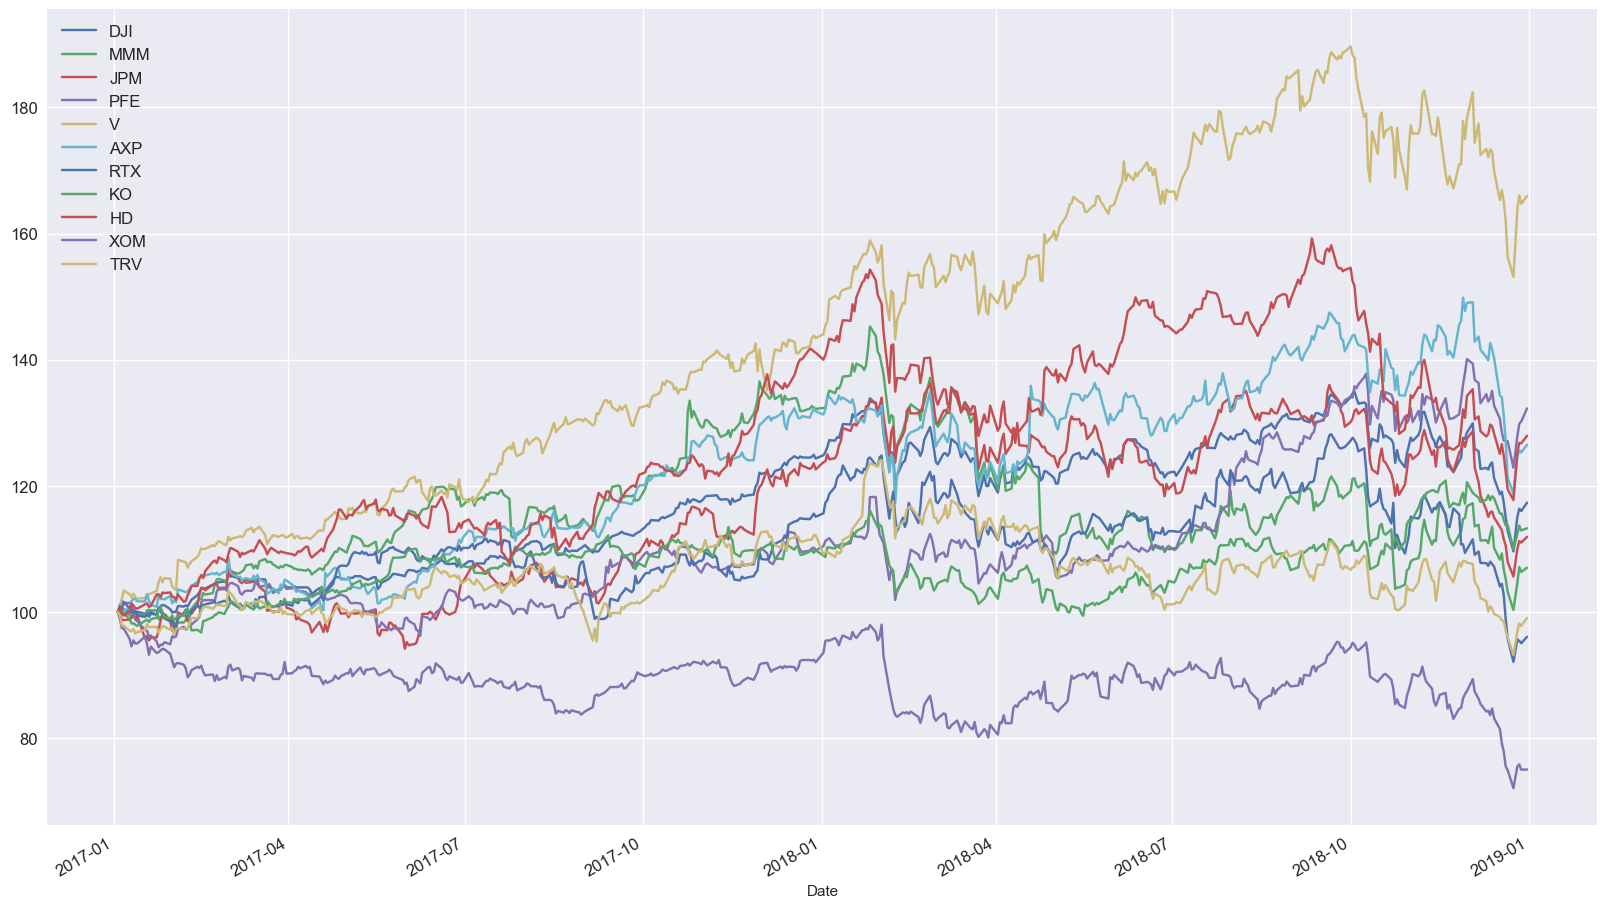

In [43]:
norm_track.plot(figsize=(20,12), fontsize=12)
plt.legend(fontsize=12)
plt.show()

Drop DJI 

In [44]:
tracking_stocks = tracking_stocks[1:]
tracking_stocks

Index(['MMM', 'JPM', 'PFE', 'V', 'AXP', 'RTX', 'KO', 'HD', 'XOM', 'TRV'], dtype='object')

## Index Tracking - A simple Tracking Portfolio

In [45]:
tracking_stocks

Index(['MMM', 'JPM', 'PFE', 'V', 'AXP', 'RTX', 'KO', 'HD', 'XOM', 'TRV'], dtype='object')

In [46]:
#equal weights (starting point of optimization)
eweights = np.full(noa, 1/noa)
eweights

array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

Calculation daily returns for eqeights(euqwel weights) portfolio

Option 1

In [47]:
ret2.loc[:, tracking_stocks].mean(axis=1)

Date
2017-01-03    0.007562
2017-01-04    0.001641
2017-01-05   -0.003983
2017-01-06    0.002168
2017-01-09   -0.004350
                ...   
2018-12-24   -0.027788
2018-12-26    0.045523
2018-12-27    0.011286
2018-12-28   -0.004372
2018-12-31    0.008403
Length: 502, dtype: float64

Option 2

In [48]:
ret2.loc[:, tracking_stocks].dot(eweights)

Date
2017-01-03    0.007562
2017-01-04    0.001641
2017-01-05   -0.003983
2017-01-06    0.002168
2017-01-09   -0.004350
                ...   
2018-12-24   -0.027788
2018-12-26    0.045523
2018-12-27    0.011286
2018-12-28   -0.004372
2018-12-31    0.008403
Length: 502, dtype: float64

In [49]:
#calculate portfolio returns (based on weights)
def port_ret(weights):
    return ret2.loc[:, tracking_stocks].dot(weights)

In [50]:
#define function to be minimized -> minimize tracking error of tracking portfolio
def tracking_error(weights): 
     return port_ret(weights).sub(ret2.DJI).std() * np.sqrt(252)

In [51]:
tracking_error(eweights)

0.04120933686266802

In [52]:
ew_port = port_ret(eweights)[1:].add(1).cumprod().mul(100)
ew_port

Date
2017-01-04    100.164136
2017-01-05     99.765133
2017-01-06     99.981424
2017-01-09     99.546547
2017-01-10     99.482801
                 ...    
2018-12-24    108.298000
2018-12-26    113.228018
2018-12-27    114.505929
2018-12-28    114.005345
2018-12-31    114.963346
Length: 501, dtype: float64

In [53]:
norm_track["EW_Port"] = ew_port
norm_track.iloc[0, 1] = 100

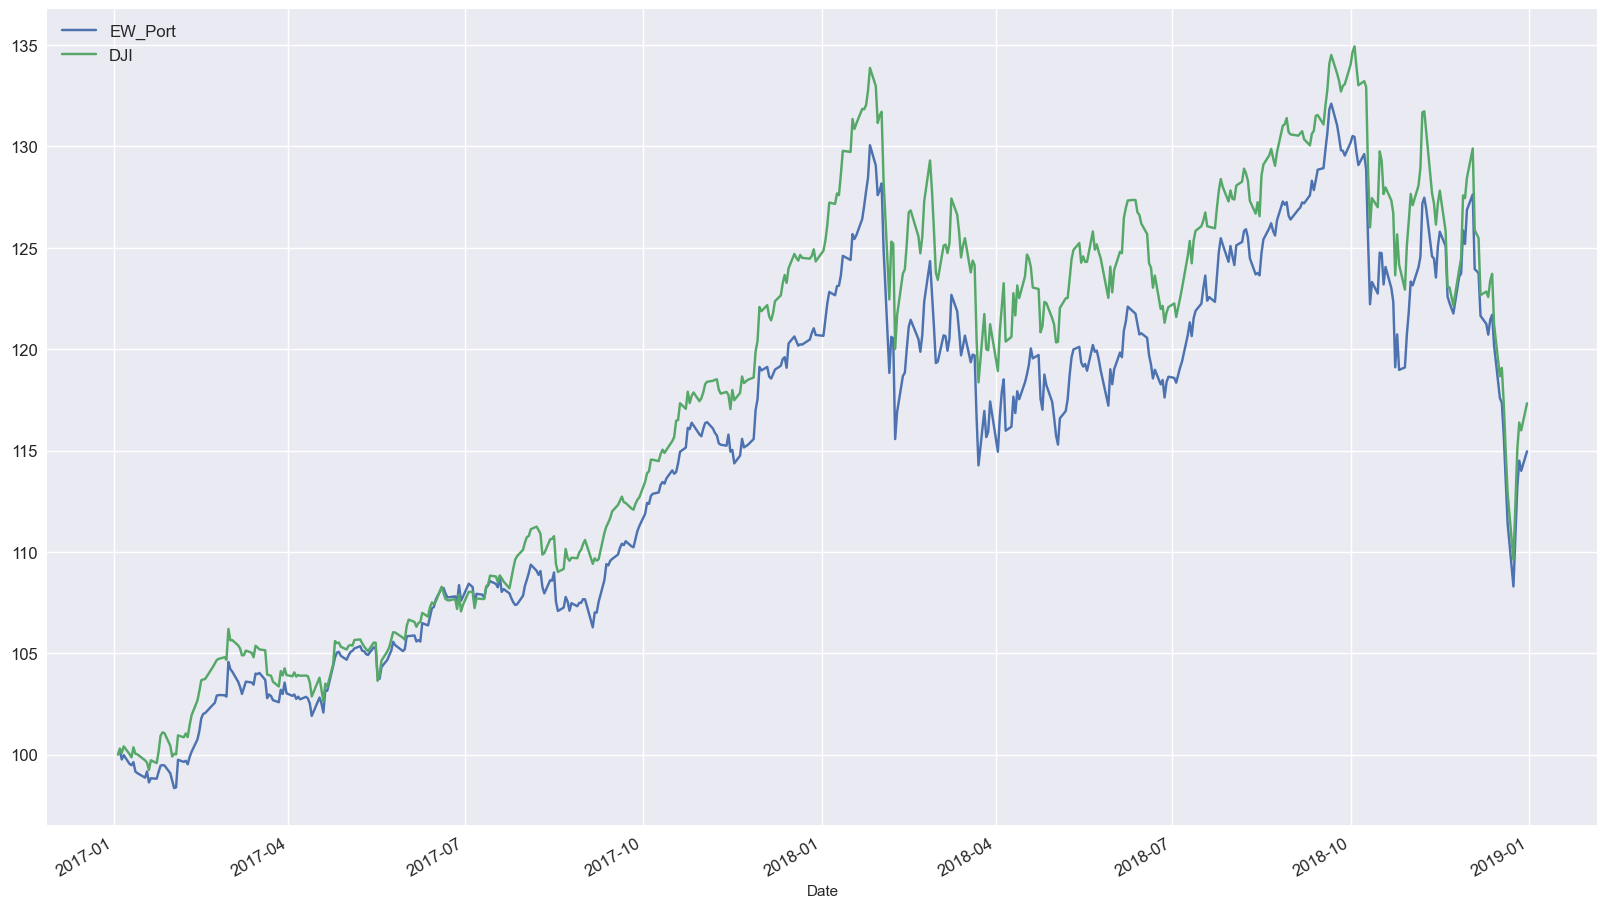

In [54]:
norm_track[["EW_Port", "DJI"]].plot(figsize=(20, 12), fontsize=12)
plt.legend(fontsize=12, loc=2)
plt.show()

## Index Tracking - The optimal Tracking Portfolio

In [55]:
import scipy.optimize as sco

In [56]:
#constraint: weights must sum up to 1 -> sum of weights - 1 = 0
cons = ({"type": "eq", "fun": lambda x: np.sum(x) - 1})
cons

{'type': 'eq', 'fun': <function __main__.<lambda>(x)>}

In [57]:
#bounds: all weights shall be between 0 and 1 -> can be changed
bnds =  tuple((0,1) for x in range(noa))
bnds

((0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 1))

In [58]:
#run optimization based on function to be minimized, starting with equal weights and based on respective bounds and constraints
opts = sco.minimize(tracking_error, eweights, method = "SLSQP", bounds = bnds, constraints= cons)
opts

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.03796156173948106
       x: [ 1.310e-01  1.445e-01  5.985e-02  1.677e-01  4.029e-02
            1.005e-01  7.688e-02  1.096e-01  1.146e-01  5.508e-02]
     nit: 7
     jac: [ 7.441e-03  7.563e-03  7.450e-03  7.411e-03  7.372e-03
            7.337e-03  7.254e-03  7.539e-03  7.372e-03  7.685e-03]
    nfev: 77
    njev: 7

In [59]:
#getting the optimal weights
optimal_weights = opts["x"]
optimal_weights

array([0.13101952, 0.14451523, 0.05984737, 0.16765083, 0.04028627,
       0.10054676, 0.07688202, 0.10956916, 0.11460304, 0.05507981])

In [60]:
pd.Series(index = tracking_stocks, data = optimal_weights)

MMM    0.131020
JPM    0.144515
PFE    0.059847
V      0.167651
AXP    0.040286
RTX    0.100547
KO     0.076882
HD     0.109569
XOM    0.114603
TRV    0.055080
dtype: float64

In [61]:
opt_port = port_ret(optimal_weights)[1:].add(1).cumprod().mul(100)
opt_port

Date
2017-01-04    100.125313
2017-01-05     99.822671
2017-01-06    100.145521
2017-01-09     99.669085
2017-01-10     99.526402
                 ...    
2018-12-24    109.460455
2018-12-26    114.706689
2018-12-27    116.037462
2018-12-28    115.455023
2018-12-31    116.345589
Length: 501, dtype: float64

In [62]:
norm_track["Opt_Port"] = opt_port
norm_track.iloc[0, -1] = 100
norm_track

,DJI,MMM,JPM,PFE,V,AXP,RTX,KO,HD,XOM,TRV,EW_Port,Opt_Port
Date,,,,,,,,,,,,,
2017-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,100.000000
2017-01-04,100.303798,100.151645,99.633154,100.878791,100.817612,101.207702,100.063159,99.641154,100.886012,98.899769,99.462364,100.164136,100.125313
2017-01-05,100.088168,99.809044,98.716035,101.848487,101.999995,99.960187,100.469184,99.880385,99.694733,97.425463,97.874277,99.765133,99.822671
2017-01-06,100.412645,100.101091,98.727501,101.454544,103.408804,100.159260,101.551928,99.856465,99.419255,97.370448,97.824644,99.981424,100.145521
2017-01-09,100.028273,99.561922,98.796282,101.424246,102.830189,100.676844,100.604537,98.851676,100.000000,95.764112,97.038874,99.546547,99.669085
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,109.609006,100.320130,105.628793,122.878786,153.119501,118.779034,92.086978,109.952153,117.742538,72.076139,93.159633,108.298000,109.460455
2018-12-26,115.072556,104.611059,110.008019,127.848481,163.811315,124.538817,95.650995,112.296649,125.292236,75.519859,96.914803,113.228018,114.706689
2018-12-27,116.382154,107.104742,111.246128,129.848480,166.050308,125.653619,95.425433,113.708133,126.811116,75.849932,98.155498,114.505929,116.037462


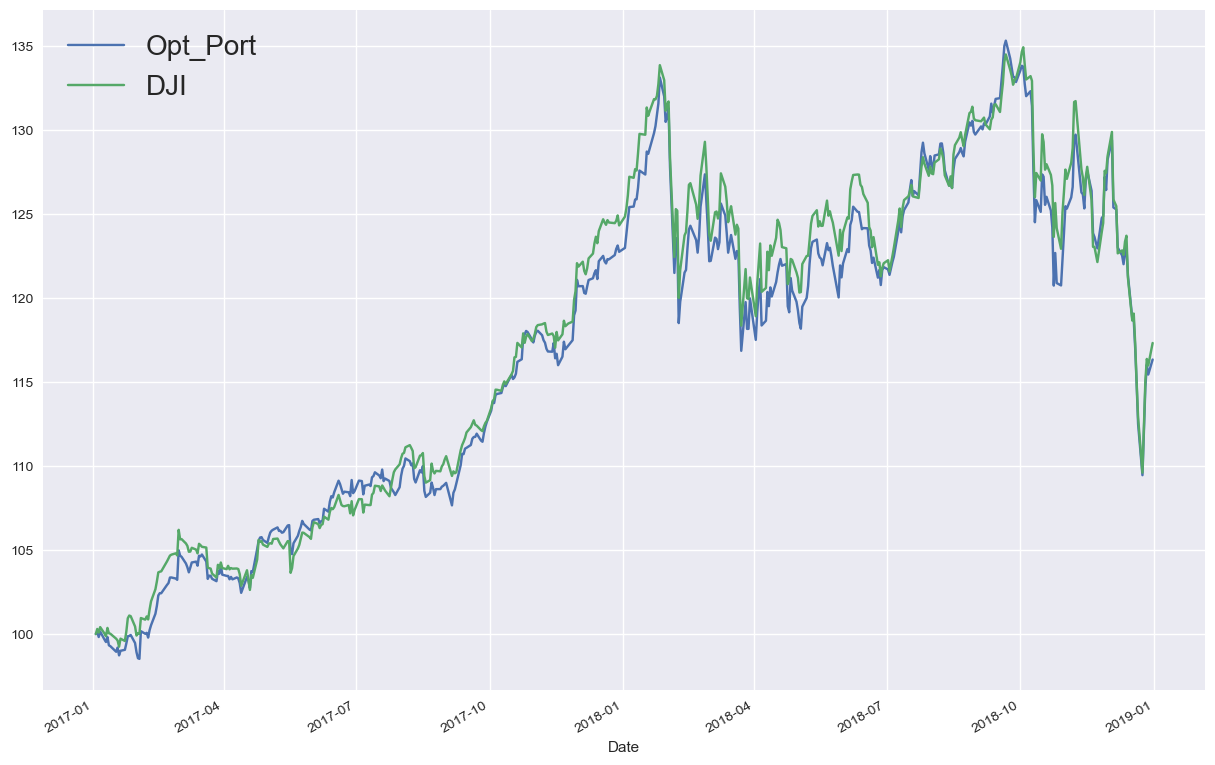

In [63]:
norm_track[["Opt_Port", "DJI"]].plot(figsize = (15, 10))
plt.legend(fontsize = 20, loc = 2)
plt.show()

In [64]:
summary_ann(norm_track[["Opt_Port", "EW_Port", "DJI"]].pct_change())

,Return,Risk
Opt_Port,0.084879,0.131867
EW_Port,0.077585,0.127262
DJI,0.089562,0.135206


## Forward Testing

In [65]:
df

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-03,11.971429,60.360001,89.169998,61.160000,27.730000,70.970001,33.738300,NaN,200.720001,41.070000,...,64.540001,39.528004,53.549999,52.570000,NaN,35.306732,46.070000,47.549999,74.110001,12474.519531
2007-01-04,12.237143,59.919998,89.529999,61.000000,28.459999,70.279999,34.004654,NaN,198.850006,40.570000,...,64.050003,39.565765,53.099998,52.910000,NaN,35.502777,46.160000,47.779999,72.720001,12480.690430
2007-01-05,12.150000,59.130001,89.150002,60.220001,28.469999,70.550003,33.728436,NaN,199.050003,39.790001,...,63.500000,39.446194,52.410000,52.549999,NaN,34.895969,45.500000,47.389999,73.239998,12398.009766
2007-01-08,12.210000,59.689999,88.940002,60.290001,28.629999,71.449997,34.034248,NaN,203.729996,39.490002,...,63.639999,39.767151,52.020000,53.320000,NaN,34.363850,45.689999,47.000000,72.650002,12423.490234
2007-01-09,13.224286,59.310001,88.000000,60.619999,28.469999,70.629997,33.984924,NaN,204.080002,39.320000,...,63.480000,39.314034,51.889999,52.680000,NaN,34.503880,45.930000,47.389999,72.089996,12416.599609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-24,246.880005,84.050003,127.680000,101.339996,38.599998,66.550003,98.120003,28.469999,153.600006,184.720001,...,103.269997,54.600376,93.739998,219.800003,154.529999,49.990002,45.250000,115.029999,35.439999,20704.910156
2020-03-25,245.520004,90.169998,158.729996,104.669998,37.669998,69.269997,100.730003,30.379999,155.130005,181.759995,...,100.919998,60.534927,92.180000,234.490005,161.779999,49.939999,41.439999,109.400002,37.290001,21200.550781
2020-03-26,258.440002,93.290001,180.550003,110.500000,40.580002,76.379997,105.360001,29.680000,165.789993,195.210007,...,107.379997,65.852737,98.669998,255.389999,168.880005,53.540001,45.669998,109.820000,38.820000,22552.169922


In [66]:
ret

,AAPL,AXP,BA,CAT,CSCO,CVX,DIS,DOW,GS,HD,...,PG,RTX,TRV,UNH,V,VZ,WBA,WMT,XOM,DJI
Date,,,,,,,,,,,,,,,,,,,,,
2007-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-04,0.022196,-0.007290,0.004037,-0.002616,0.026325,-0.009722,0.007895,NaN,-0.009316,-0.012174,...,-0.007592,0.000955,-0.008403,0.006468,NaN,0.005553,0.001954,0.004837,-0.018756,0.000495
2007-01-05,-0.007121,-0.013184,-0.004244,-0.012787,0.000351,0.003842,-0.008123,NaN,0.001006,-0.019226,...,-0.008587,-0.003022,-0.012994,-0.006804,NaN,-0.017092,-0.014298,-0.008162,0.007151,-0.006625
2007-01-08,0.004938,0.009471,-0.002356,0.001162,0.005620,0.012757,0.009067,NaN,0.023512,-0.007540,...,0.002205,0.008137,-0.007441,0.014653,NaN,-0.015249,0.004176,-0.008230,-0.008056,0.002055
2007-01-09,0.083070,-0.006366,-0.010569,0.005474,-0.005589,-0.011477,-0.001449,NaN,0.001718,-0.004305,...,-0.002514,-0.011394,-0.002499,-0.012003,NaN,0.004075,0.005253,0.008298,-0.007708,-0.000555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-24,0.100325,0.218823,0.208862,0.103321,0.115607,0.227407,0.144123,0.071106,0.138031,0.137508,...,0.057011,0.157572,0.060887,0.127989,0.138426,-0.006361,0.037606,0.006563,0.126868,0.113650
2020-03-25,-0.005509,0.072814,0.243186,0.032860,-0.024093,0.040871,0.026600,0.067088,0.009961,-0.016024,...,-0.022756,0.108691,-0.016642,0.066833,0.046916,-0.001000,-0.084199,-0.048944,0.052201,0.023938
2020-03-26,0.052623,0.034601,0.137466,0.055699,0.077250,0.102642,0.045964,-0.023041,0.068716,0.073999,...,0.064011,0.087847,0.070406,0.089130,0.043887,0.072087,0.102075,0.003839,0.041030,0.063754


In [67]:
tracking_stocks

Index(['MMM', 'JPM', 'PFE', 'V', 'AXP', 'RTX', 'KO', 'HD', 'XOM', 'TRV'], dtype='object')

In [68]:
def tracking_error_gen(data, tracking_stock, eweights, index, start, end):
    return data.loc[start:end, tracking_stock].dot(eweights).sub(ret.loc[start:end, index]).std()*np.sqrt(252)  

In [77]:
def visual(data, tracking_stock, eweights, index, start, end):
    track = data.loc[start:end, tracking_stock].dot(eweights).add(1).cumprod().mul(100)
    track.name = "Portfolio"
    index = data.loc[start:end, index].add(1).cumprod().mul(100)
    plt.figure(figsize=(20,12))
    track.plot()
    index.plot()
    plt.legend(fontsize=12)
    plt.show()

In [70]:
tracking_error_gen(ret, tracking_stocks, optimal_weights, "DJI", "2017-01-01", "2018-12-31")

0.03796156173948106

In [72]:
fwd_trascking = tracking_error_gen(ret, tracking_stocks, optimal_weights, "DJI", "2019-01-01", "2019-12-31")
fwd_trascking

0.047843032410449626

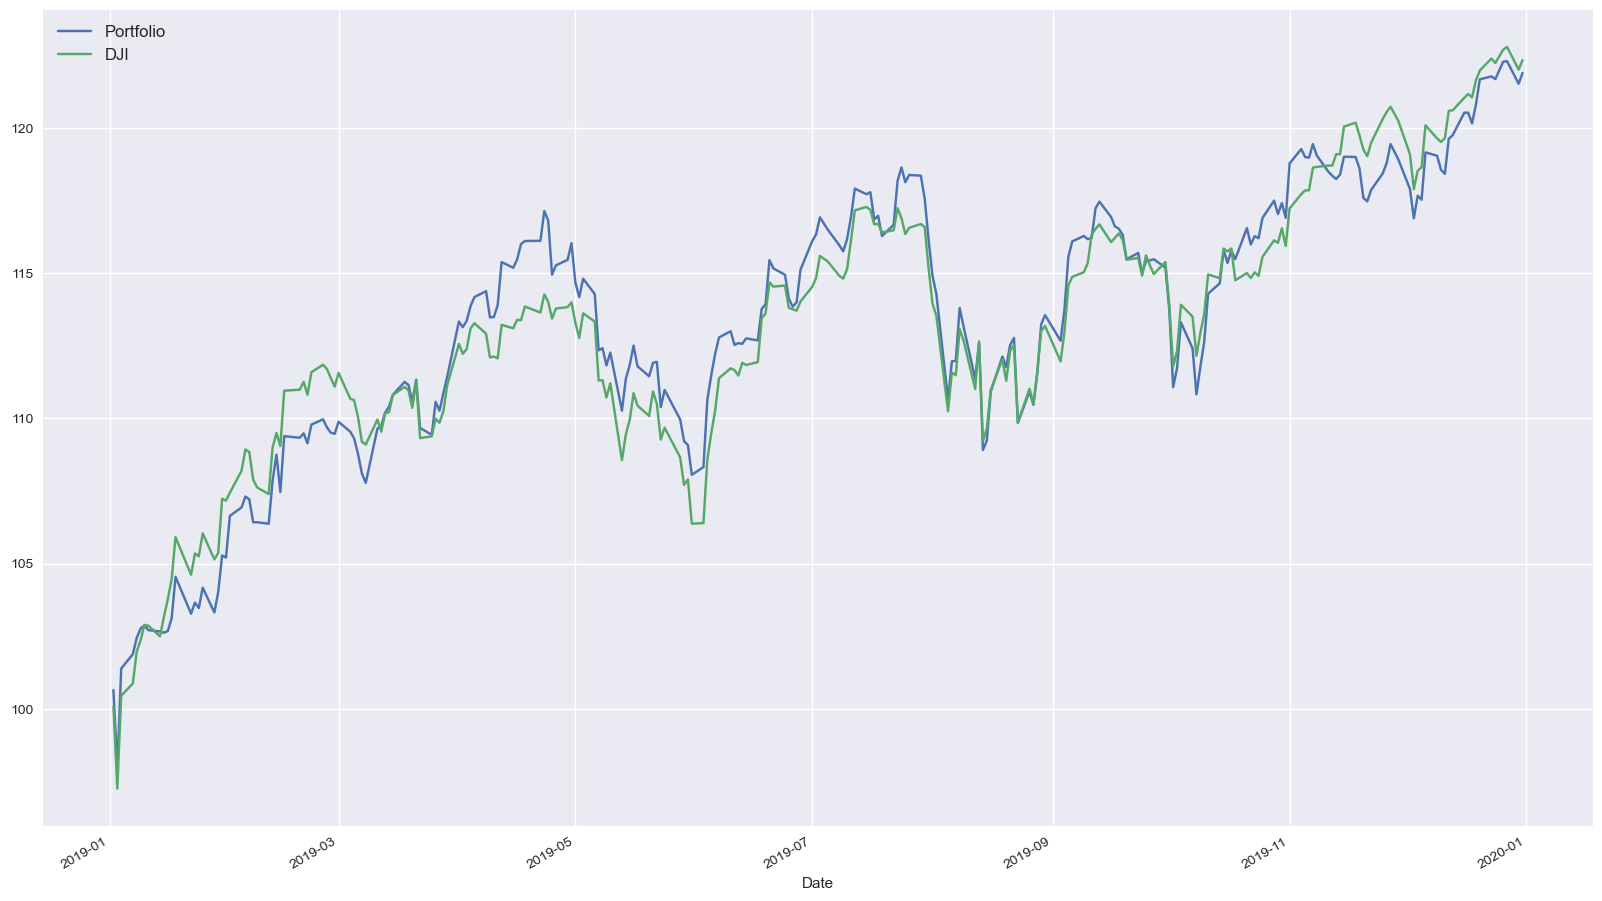

In [78]:
visual(ret, tracking_stocks, optimal_weights, "DJI", "2019-01-01", "2019-12-31")

In [79]:
bucket = df.columns.drop(["DOW", "DJI"])
bucket

Index(['AAPL', 'AXP', 'BA', 'CAT', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'IBM',
       'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PFE',
       'PG', 'RTX', 'TRV', 'UNH', 'V', 'VZ', 'WBA', 'WMT', 'XOM'],
      dtype='object')

In [80]:
np.random.choice(bucket, size=noa, replace=False)

array(['HD', 'MMM', 'INTC', 'V', 'JNJ', 'AAPL', 'MCD', 'CVX', 'WBA',
       'TRV'], dtype=object)

In [85]:
random_numbers = np.random.random(noa)
random_weight = random_numbers / random_numbers.sum()
random_weight

array([0.11674846, 0.11771769, 0.13412331, 0.13504344, 0.02775678,
       0.02613152, 0.14136774, 0.0468496 , 0.07030205, 0.18395941])

In [88]:
np.random.seed(123)
random_stocks = np.random.choice(bucket, size=noa, replace=False)
random_numbers = np.random.random(noa)
random_weights = random_numbers / random_numbers.sum()

In [89]:
print(random_stocks, random_weights)

['GS' 'XOM' 'CVX' 'VZ' 'HD' 'WBA' 'JPM' 'RTX' 'JNJ' 'TRV'] [0.0858475  0.05974735 0.098733   0.14853474 0.07177554 0.08370995
 0.13136476 0.07500036 0.04705319 0.19823361]


In [90]:
tracking_error_gen(ret, random_stocks, random_weights, "DJI", "2019-01-01", "2019-12-31")

0.055536608820316934

In [91]:
fwd_trascking

0.047843032410449626

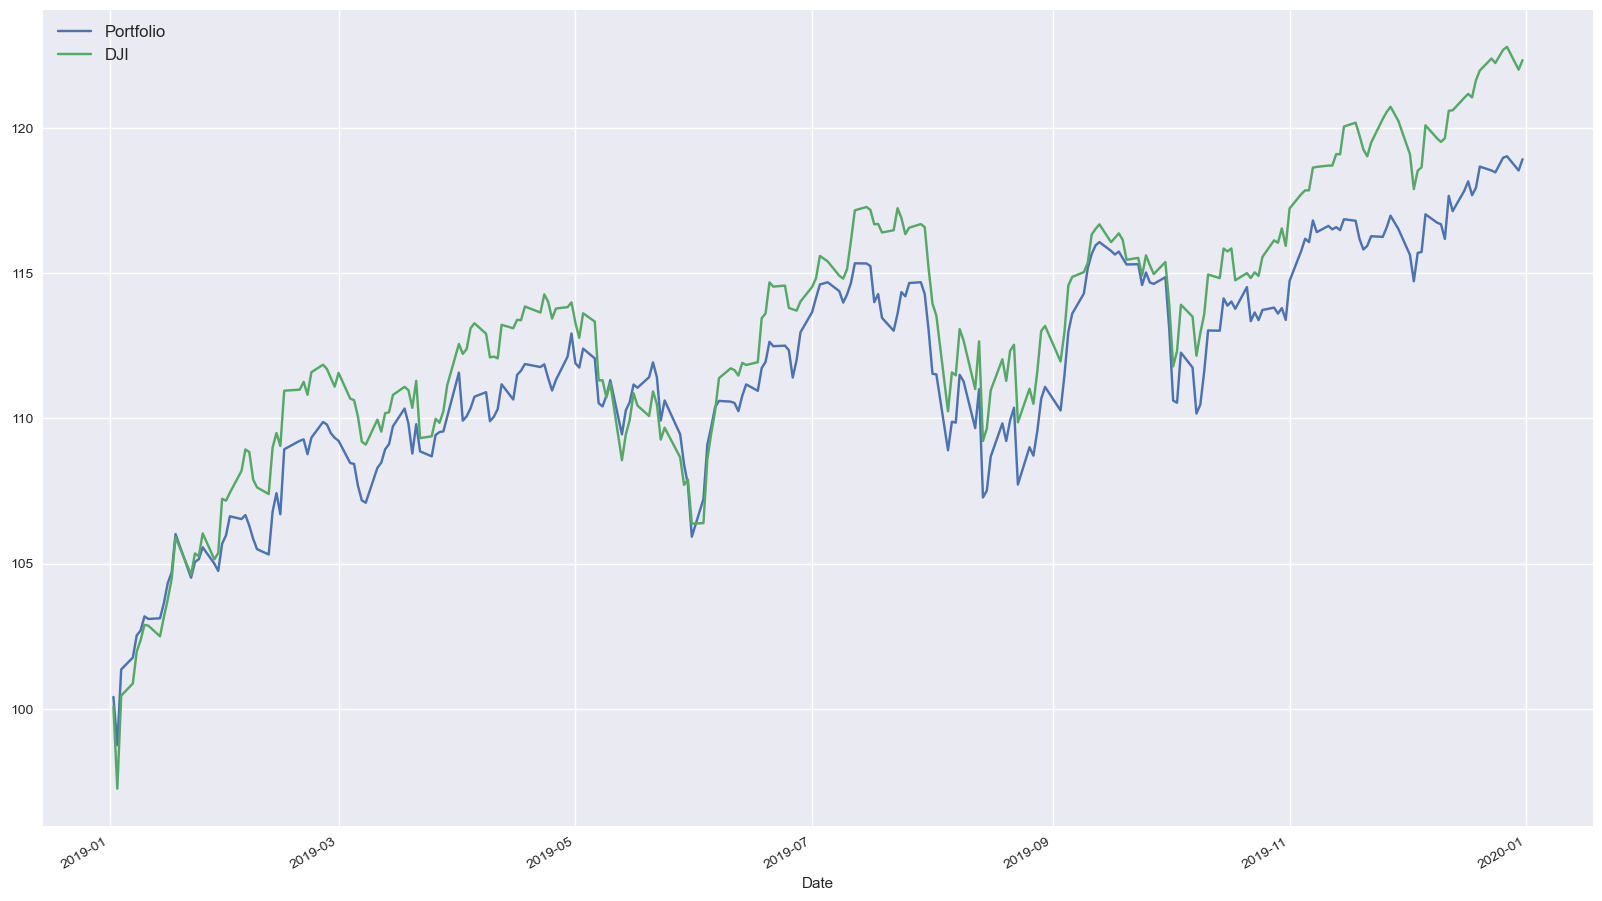

In [92]:
visual(ret, random_stocks, random_weights, "DJI", "2019-01-01", "2019-12-31")

In [94]:
test = np.empty(10000)
np.random.seed(123)
for i in range(10000):
    random_stocks = np.random.choice(bucket, size=noa, replace=False)
    random_numbers = np.random.random(noa)
    random_weights = random_numbers / random_numbers.sum()
    test[i] = tracking_error_gen(ret, random_stocks, random_weights, "DJI", "2019-01-01", "2019-12-31")

In [95]:
(test < fwd_trascking).mean()

0.0736

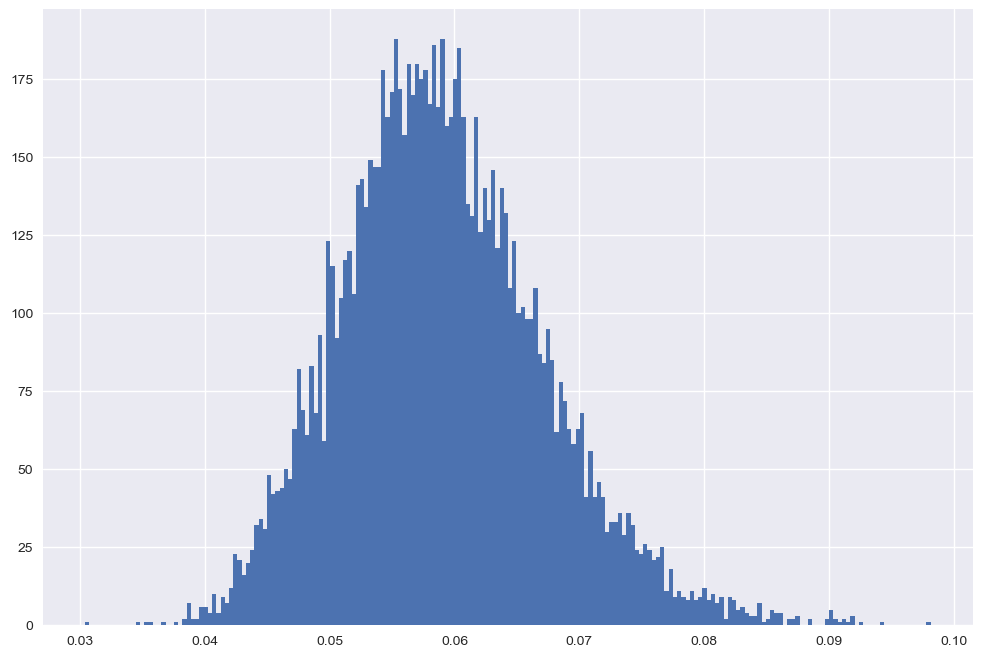

In [103]:
plt.figure(figsize=(12,8))
plt.hist(test, bins=200)
plt.show()